# AVOCADO PRICE PREDICTON USING PCA

In [219]:
from sklearn import datasets
import pandas as pd

from plotnine import *
import janitor
import numpy as np

In [220]:
avocado = pd.read_csv('C:/Users/HP/Downloads/avocado.csv')
avocado = avocado.clean_names()
avocado.head()

,unnamed_0,date,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


# Converting into Datetime format and Separating the values into different columns

In [221]:
avocado['date'] = pd.to_datetime(avocado['date'])

In [222]:
avocado['month'] = avocado['date'].dt.month
avocado['day'] = avocado['date'].dt.day
avocado['year'] = avocado['date'].dt.year

avocado.head()


,unnamed_0,date,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region,month,day
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,12,27
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,12,20
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,12,13
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,12,6
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,11,29


# Turning the 'TYPE' column into binary

In [223]:
avocado['type'] = avocado['type'].map({'organic': 1, 'conventional': 0})
avocado['type']

0        0
1        0
2        0
3        0
4        0
        ..
18244    1
18245    1
18246    1
18247    1
18248    1
Name: type, Length: 18249, dtype: int64

# Dropping of Variables

In [224]:
avocado = avocado.drop(['unnamed_0'], axis = 1)
avocado = avocado.drop(['date'], axis = 1)
avocado = avocado.drop(['total_bags'], axis = 1)
avocado = avocado.drop(['region'], axis = 1)

In [225]:
avocado.duplicated().sum()

np.int64(0)

In [226]:
avocado.isna().sum()

averageprice    0
total_volume    0
4046            0
4225            0
4770            0
small_bags      0
large_bags      0
xlarge_bags     0
type            0
year            0
month           0
day             0
dtype: int64

In [227]:
avocado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   averageprice  18249 non-null  float64
 1   total_volume  18249 non-null  float64
 2   4046          18249 non-null  float64
 3   4225          18249 non-null  float64
 4   4770          18249 non-null  float64
 5   small_bags    18249 non-null  float64
 6   large_bags    18249 non-null  float64
 7   xlarge_bags   18249 non-null  float64
 8   type          18249 non-null  int64  
 9   year          18249 non-null  int32  
 10  month         18249 non-null  int32  
 11  day           18249 non-null  int32  
dtypes: float64(8), int32(3), int64(1)
memory usage: 1.5 MB


In [228]:
avocado.describe()

,averageprice,total_volume,4046,4225,4770,small_bags,large_bags,xlarge_bags,type,year,month,day
count,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000,18249.000000,18249.000000,18249.000000
mean,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,1.821947e+05,5.433809e+04,3106.426507,0.499918,2016.147899,6.177215,15.662612
std,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,7.461785e+05,2.439660e+05,17692.894652,0.500014,0.939938,3.534130,8.776281
min,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,2015.000000,1.000000,1.000000
25%,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,2.849420e+03,1.274700e+02,0.000000,0.000000,2015.000000,3.000000,8.000000
50%,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,2.636282e+04,2.647710e+03,0.000000,0.000000,2016.000000,6.000000,16.000000
75%,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,8.333767e+04,2.202925e+04,132.500000,1.000000,2017.000000,9.000000,23.000000
max,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.338459e+07,5.719097e+06,551693.650000,1.000000,2018.000000,12.000000,31.000000


In [229]:
avocado.keys()

Index(['averageprice', 'total_volume', '4046', '4225', '4770', 'small_bags',
       'large_bags', 'xlarge_bags', 'type', 'year', 'month', 'day'],
      dtype='object')

In [230]:
avocado.isna().sum()

averageprice    0
total_volume    0
4046            0
4225            0
4770            0
small_bags      0
large_bags      0
xlarge_bags     0
type            0
year            0
month           0
day             0
dtype: int64

In [231]:
avocado.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
18244    False
18245    False
18246    False
18247    False
18248    False
Length: 18249, dtype: bool

# Standardization Of The Dataset

In [239]:
from sklearn.preprocessing import StandardScaler

avocado_sca = StandardScaler()
avocado_scaled = avocado_sca.fit_transform(avocado)
avocado_scaled

avocado_scaled_df = pd.DataFrame(avocado_scaled, columns = avocado.columns)
avocado_scaled_df.head()

,averageprice,total_volume,4046,4225,4770,small_bags,large_bags,xlarge_bags,type,year,month,day
0,-0.188689,-0.227716,-0.230816,-0.199902,-0.212091,-0.232647,-0.222352,-0.17558,-0.999836,-1.221282,1.647632,1.291857
1,-0.139020,-0.230427,-0.231103,-0.208054,-0.211997,-0.231568,-0.222335,-0.17558,-0.999836,-1.221282,1.647632,0.494231
2,-1.182069,-0.212085,-0.231007,-0.154478,-0.211325,-0.233399,-0.222311,-0.17558,-0.999836,-1.221282,1.647632,-0.303396
3,-0.809551,-0.223444,-0.230741,-0.185350,-0.211864,-0.236568,-0.222186,-0.17558,-0.999836,-1.221282,1.647632,-1.101022
4,-0.312861,-0.231538,-0.230891,-0.208719,-0.211834,-0.236154,-0.221924,-0.17558,-0.999836,-1.221282,1.364669,1.519750


# Application of the pca

In [240]:
from sklearn.decomposition import PCA
pca= PCA()
avocado_scaled_pca = pca.fit(avocado_scaled_df)
avocado_scaled_pca

avocado_pca = pca.transform(avocado_scaled_df)
print(avocado_scaled.shape)
print(avocado_pca.shape)

(18249, 12)
(18249, 12)


In [241]:
explained_variance = pca.explained_variance_ratio_
explained_variance

array([5.12894971e-01, 1.27343621e-01, 9.86338391e-02, 8.34010279e-02,
       7.05879731e-02, 3.32933003e-02, 2.99486964e-02, 2.46780230e-02,
       1.08700490e-02, 5.35327873e-03, 2.99522067e-03, 1.29271742e-11])

# Taking of the scree plot

In [242]:
explained_variance_df = pd.DataFrame({"features": range(1, 13),
             "EVR": explained_variance})

explained_variance_df.head()

,features,EVR
0,1,0.512895
1,2,0.127344
2,3,0.098634
3,4,0.083401
4,5,0.070588


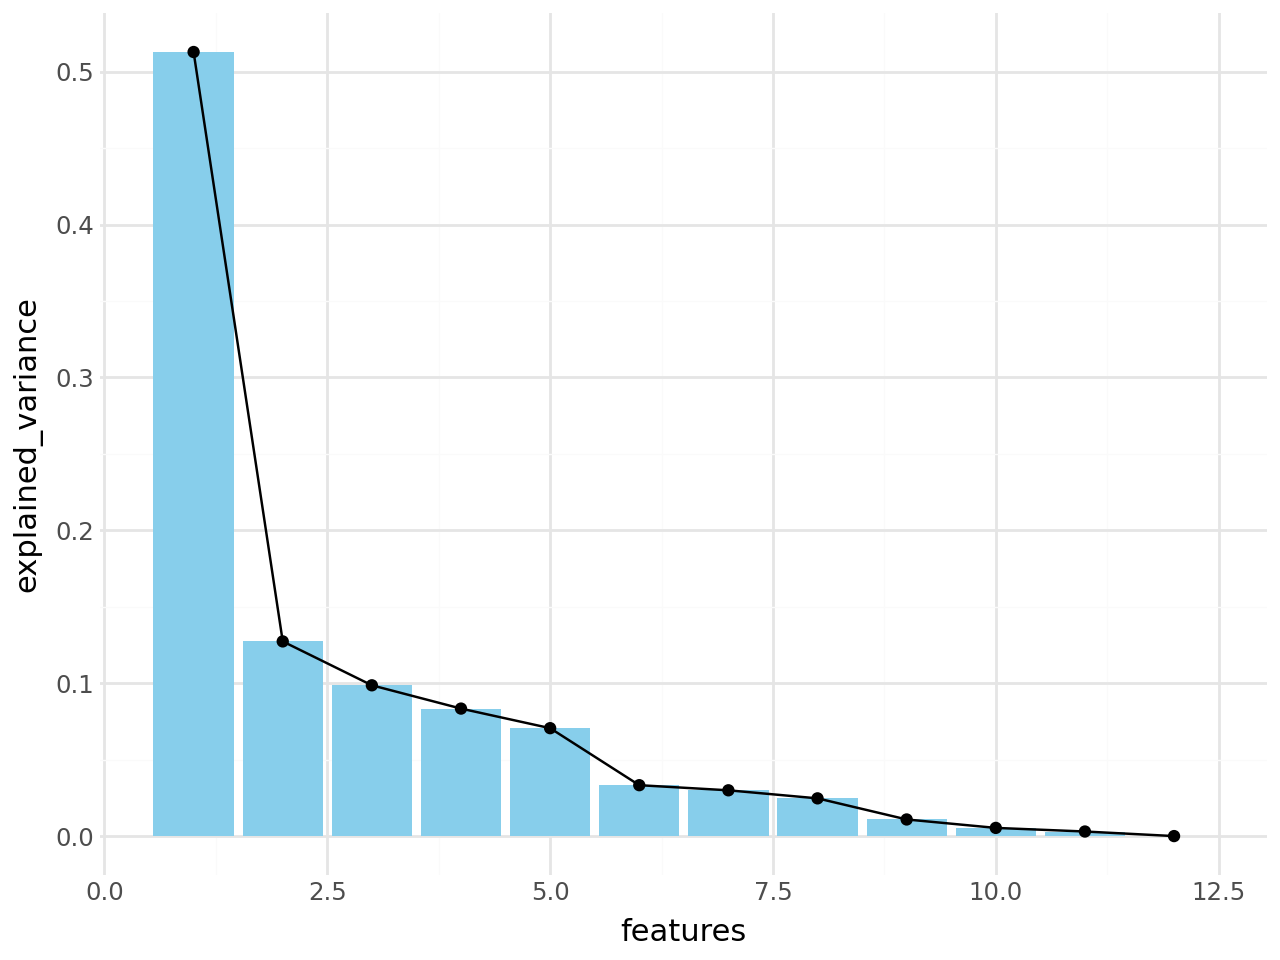

In [243]:
(ggplot(explained_variance_df, aes("features", "explained_variance"))
+ geom_col(fill = "skyblue")
+ geom_line()
+ geom_point()
+ theme_minimal())

# Inspection of the Pca Components

In [244]:
loadings = pd.DataFrame(pca.components_.T, columns = [f'PC{i+1}' for i in range(len(avocado.columns))], index = avocado.columns)
print(loadings)

                   PC1       PC2       PC3       PC4       PC5       PC6  \
averageprice -0.103382  0.706766  0.001579 -0.004840  0.042743 -0.073561   
total_volume  0.398446  0.055404 -0.017799 -0.005084 -0.030995 -0.159235   
4046          0.385571  0.040506 -0.026167 -0.006914 -0.046732 -0.214805   
4225          0.385158  0.053095 -0.041479 -0.010606 -0.060656 -0.299295   
4770          0.357654  0.038649 -0.054579 -0.010532 -0.109105 -0.258141   
small_bags    0.391452  0.071906  0.020904  0.005696  0.027305  0.090194   
large_bags    0.361641  0.068818  0.045168  0.002305  0.061216  0.113281   
xlarge_bags   0.326556  0.088611  0.046466  0.015807  0.086243  0.847247   
type         -0.120555  0.659057  0.058071 -0.066937 -0.314016  0.044109   
year          0.013145  0.101234  0.720042  0.057992  0.638576 -0.155974   
month        -0.015519  0.166823 -0.683785  0.034907  0.673634 -0.041507   
day          -0.004494  0.035577 -0.016316  0.995153 -0.085707 -0.009309   

           

# Spliiting Of the Dataset into X_train and test

In [245]:
import janitor
independent_variable = avocado.drop('type', axis = 1)
dependent_variable = avocado['type']

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(independent_variable, dependent_variable, test_size = 0.2, random_state = 42)


# Standardization of the splitted features

In [139]:
from sklearn.preprocessing import StandardScaler

x_train_sca = StandardScaler()
x_train_scaled = x_train_sca.fit_transfor(x_train)
x_train_scaled

x_train_scaled_df = pd.DataFrame(x_train_scaled, columns = x_train.columns)
x_train_scaled_df.head()

,averageprice,total_volume,4046,4225,4770,small_bags,large_bags,xlarge_bags,year,month,day
0,1.178674,-0.247683,-0.235928,-0.245519,-0.211662,-0.241658,-0.224957,-0.177018,0.905234,1.360639,-0.415019
1,-1.475662,-0.079312,-0.110923,-0.118244,-0.011670,-0.049399,0.206852,-0.177018,-0.158217,-1.471649,-0.642903
2,1.501164,-0.247362,-0.234417,-0.244132,-0.211662,-0.245084,-0.224710,-0.177018,-0.158217,1.360639,1.294109
3,-0.954717,-0.206482,-0.173141,-0.213823,-0.210415,-0.212047,-0.214273,-0.177018,-1.221669,-1.188420,-0.870786
4,0.310433,-0.237356,-0.235916,-0.213896,-0.211662,-0.245293,-0.224985,-0.177018,-0.158217,-0.055505,-0.415019


In [257]:
from sklearn.decomposition import PCA

pca_2 = PCA(n_components = 3)
pca_2.fit(x_train_scaled_df)

x_train_pca = pca_2.transform(x_train_scaled_df)

x_train_pca.shape

x_train_pca_df = pd.DataFrame({"pca_1" : x_train_pca[:, 0],
                               "pca_2" : x_train_pca[:, 1],
                               "pca_3" : x_train_pca[:, 2]
                              })
x_train_pca_df.head()

,pca_1,pca_2,pca_3
0,-0.712815,0.668739,1.560411
1,0.025962,-1.347329,-1.711349
2,-0.757990,1.450796,1.649157
3,-0.439588,-0.373824,-1.919729
4,-0.612722,0.090708,-0.009155


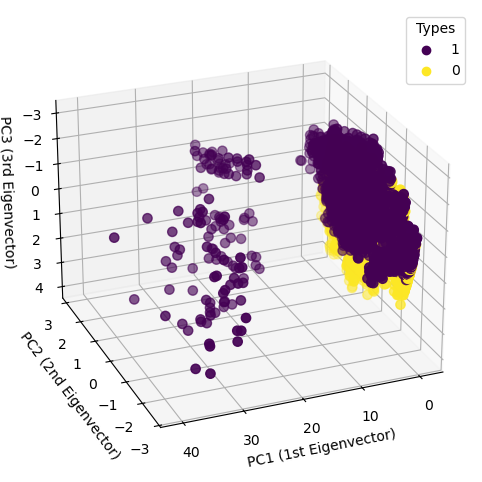

In [258]:
import matplotlib.pyplot as plt

fig = plt.figure(1, figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d", elev=-155, azim=112)
# scatter plot of eigen vectors
sctr = ax.scatter(x_train_pca[:, 0], x_train_pca[:, 1], x_train_pca[:, 2],
           c = y_train, s=45,)
ax.legend(sctr.legend_elements()[0], y_train,
          loc="upper right", title="Types")

ax.set_xlabel("PC1 (1st Eigenvector)")
#ax.xaxis.set_ticklabels([])
ax.set_ylabel("PC2 (2nd Eigenvector)")
#ax.yaxis.set_ticklabels([])
ax.set_zlabel("PC3 (3rd Eigenvector)")
#ax.zaxis.set_ticklabels([])

plt.show()

In [261]:
from sklearn.linear_model import LogisticRegression

x_train_model = LogisticRegression()
x_train_model.fit(x_train_pca_df[["pca_1", "pca_2", "pca_3"]], y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [262]:
x_train_model.intercept_

array([-6.6053262])

In [264]:
x_train_model.coef_

array([[-13.78392888,  -0.45308761,   0.11995117]])

# Model Evaluation

In [267]:
x_train_pred = x_train_model.predict(x_train_pca_df[["pca_1", "pca_2", "pca_3"]])
x_train_pred

array([1, 0, 1, ..., 1, 0, 1], shape=(14599,))

In [269]:
from sklearn import metrics
print("\n Classification report for classifier %s:\n%s\n"
      % (x_train_model, metrics.classification_report(y_train, x_train_pred)))


 Classification report for classifier LogisticRegression():
              precision    recall  f1-score   support

           0       0.93      0.88      0.90      7306
           1       0.88      0.93      0.91      7293

    accuracy                           0.90     14599
   macro avg       0.90      0.90      0.90     14599
weighted avg       0.90      0.90      0.90     14599




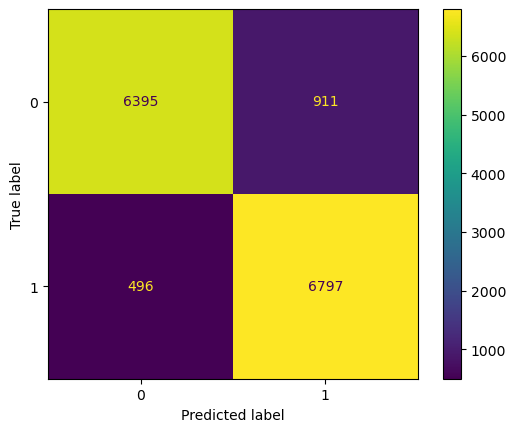

In [271]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_train, x_train_pred)
plt.show()

# TESTING OF OUR MODEL

In [276]:
x_train_sca = StandardScaler()
x_train_scaled2 = x_train_sca.fit(x_train)
x_train_scaled2

x_test_scaled = x_train_scaled2.transform(x_test)

x_test_scaled_df = pd.DataFrame(x_test_scaled, columns = x_test.columns)

x_test_scaled_df.head()


,averageprice,total_volume,4046,4225,4770,small_bags,large_bags,xlarge_bags,year,month,day
0,-1.450855,-0.185134,-0.172302,-0.224202,-0.183798,-0.147144,-0.082020,-0.063254,1.968686,-1.188420,-0.528961
1,-1.078752,-0.134266,-0.052370,-0.185396,-0.210727,-0.186766,-0.033925,-0.177018,-1.221669,1.360639,-1.668380
2,0.087172,-0.248115,-0.235124,-0.246214,-0.211662,-0.243894,-0.224971,-0.177018,-0.158217,-1.471649,0.952284
3,-1.078752,-0.170559,-0.114746,-0.223642,-0.206406,-0.145404,-0.162902,-0.177018,-0.158217,-0.905191,-1.098670
4,0.111978,-0.246676,-0.235380,-0.246245,-0.211662,-0.237407,-0.222831,-0.177018,0.905234,-1.188420,0.382574


# Application of the pca into the test model

In [279]:
x_test_pca = pca_2.transform(x_test_scaled_df)

x_test_pca.shape

(3650, 3)

In [280]:
x_test_pca_df = pd.DataFrame({"pca_1" : x_test_pca[:, 0],
                               "pca_2" : x_test_pca[:, 1],
                               "pca_3" : x_test_pca[:, 2]
                              })
x_test_pca_df.head()

,pca_1,pca_2,pca_3
0,-0.231446,-2.464809,-0.442132
1,-0.296031,1.480422,-1.587822
2,-0.592938,-0.976360,-0.174520
3,-0.339073,-0.858516,-1.415526
4,-0.581494,-1.439501,0.349748


# Making the plot

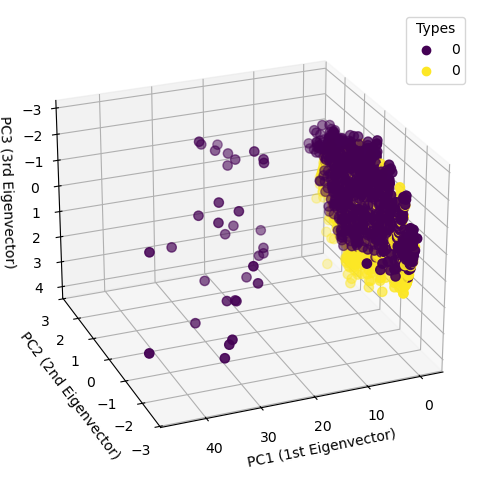

In [283]:
fig = plt.figure(1, figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d", elev=-155, azim=112)
# scatter plot of eigen vectors
sctr = ax.scatter(x_test_pca[:, 0], x_test_pca[:, 1], x_test_pca[:, 2],
           c = y_test, s=45,)
ax.legend(sctr.legend_elements()[0], y_test,
          loc="upper right", title="Types")

ax.set_xlabel("PC1 (1st Eigenvector)")
#ax.xaxis.set_ticklabels([])
ax.set_ylabel("PC2 (2nd Eigenvector)")
#ax.yaxis.set_ticklabels([])
ax.set_zlabel("PC3 (3rd Eigenvector)")

plt.show()

In [285]:
y_pred = x_train_model.predict(x_test_pca_df)
y_pred

array([0, 0, 1, ..., 0, 1, 1], shape=(3650,))

In [287]:
from sklearn import metrics
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.87      0.90      1820
           1       0.88      0.94      0.91      1830

    accuracy                           0.91      3650
   macro avg       0.91      0.91      0.91      3650
weighted avg       0.91      0.91      0.91      3650



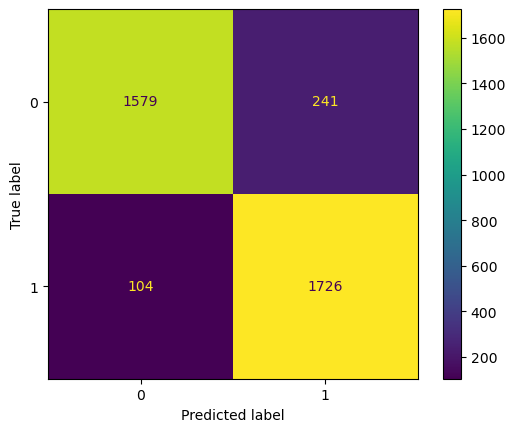

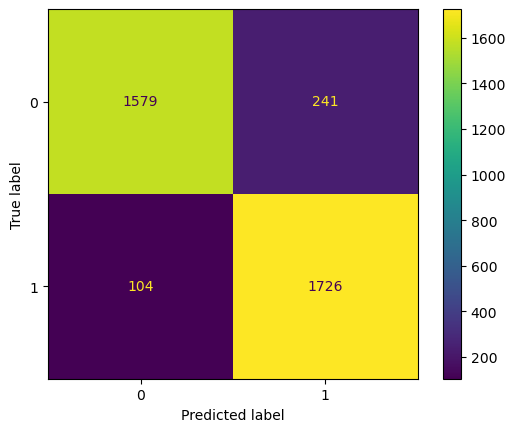

In [288]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pylab as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred).plot()
plt.show()